# Supplemental Figure 3 — Strictness vs Sensitivity

## Workflow overview
- Panel A (strict) uses the filtered MaxQuant export already packaged inside the LCMS ZIP.
- Panel B (sensitivity) toggles via `SENSITIVITY_PRESET` between the leading-only and expand-all rules (both enforce ≥2 distinct peptide sequences).
- Panel C extends Panel A's missed PFAM union transcripts with the expand-all, ≥1 peptide upper bound.
- All PNG outputs (panels, tables, JSON) land directly in `figure_files`, so the run directory is clean.
- Requires `matplotlib-venn` (install with `pip install matplotlib-venn`).
- Overlap tables and JSON counts are written alongside the figures for supplement-ready reporting.


In [1]:
!pip install matplotlib-venn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import importlib
import json
import sys
from pathlib import Path
from pprint import pprint


def find_sup_fig3_dir(start_dir: Path) -> Path:
    cur = start_dir.resolve()
    visited = set()
    while True:
        if cur in visited:
            break
        visited.add(cur)
        direct = cur / 'Sup_Figure_3_module.py'
        if direct.exists():
            return cur
        nested = cur / 'Sup_Figure_3'
        if (nested / 'Sup_Figure_3_module.py').exists():
            return nested
        if cur.parent == cur:
            break
        cur = cur.parent
    raise FileNotFoundError(f"Could not find Sup_Figure_3_module.py relative to {start_dir}")

START_DIR = Path.cwd()
SUP_FIG3_DIR = find_sup_fig3_dir(START_DIR)
if str(SUP_FIG3_DIR) not in sys.path:
    sys.path.insert(0, str(SUP_FIG3_DIR))

import Sup_Figure_3_module as s3
importlib.reload(s3);

OUTPUT_SUBDIR = None
SENSITIVITY_PRESET = 'leading_2peps'  # or 'expandAll_2peps'

paths = s3.resolve_sup_fig3_inputs(start_dir=START_DIR, outputs_subdir=OUTPUT_SUBDIR)
print('Resolved Sup_Figure_3 paths:')
pprint(paths)



Resolved Sup_Figure_3 paths:
{'ac_csv': PosixPath('/Users/alvarens/Downloads/Manuscript/Sup_Figure_3/data_files/ac_pfam_both_hits_final.csv'),
 'base_dir': PosixPath('/Users/alvarens/Downloads/Manuscript/Sup_Figure_3'),
 'bd_csv': PosixPath('/Users/alvarens/Downloads/Manuscript/Sup_Figure_3/data_files/bd_pfam_both_hits_final.csv'),
 'data_dir': PosixPath('/Users/alvarens/Downloads/Manuscript/Sup_Figure_3/data_files'),
 'figure_data_dir': PosixPath('/Users/alvarens/Downloads/Manuscript/Sup_Figure_3/figure_data'),
 'figure_dir': PosixPath('/Users/alvarens/Downloads/Manuscript/Sup_Figure_3/figure_files'),
 'out_dir': PosixPath('/Users/alvarens/Downloads/Manuscript/Sup_Figure_3/figure_files'),
 'zip_path': PosixPath('/Users/alvarens/Downloads/Manuscript/Sup_Figure_3/data_files/20251027_Mouse_Ovary_Manuscript_LCMS.zip')}


In [3]:
print('[SupFig3] Configuring gridspec + font parameters...')
PANEL_STYLE = s3.SupFigure3PanelStyle(
    figsize=(8.0, 11),
    width_ratios=(1.0, 1.0),
    wspace=0.4,
    panel_labels=('A', 'B'),
    panel_label_offsets=((-0.01, 0.02), (-0.01, 0.02)),
    panel_label_fontsize=14,
    single_panel_size=(5.5, 5.5),
    dpi=600,
    venn_title_fontsize=9,
    venn_set_label_fontsizes=(8, 8.5),
)
s3.apply_sup_fig3_style(PANEL_STYLE)
PANEL_STYLE


[SupFig3] Configuring gridspec + font parameters...


SupFigure3PanelStyle(figsize=(8.0, 11), width_ratios=(1.0, 1.0), wspace=0.4, panel_labels=('A', 'B'), panel_label_offsets=((-0.01, 0.02), (-0.01, 0.02)), panel_label_fontsize=14, single_panel_size=(5.5, 5.5), dpi=600, font_family='sans-serif', font_preferences=('Arial', 'DejaVu Sans', 'Liberation Sans'), base_fontsize=8.0, title_size=7.0, label_size=7.0, legend_size=7.0, tick_label_size=7.0, venn_title_fontsize=9, venn_set_label_fontsizes=(8, 8.5), venn_colors=('#4C72B0', '#DD8452'), venn_alpha=0.6, panel_c_figsize=(6.0, 3.2), panel_c_colors=('#55A868', '#C44E52'), panel_c_hide_box=False)

In [4]:
import pandas as pd

AC = paths['ac_csv']
BD = paths['bd_csv']
ZIP = paths['zip_path']
FIGURE_DIR = paths['figure_dir']
FIGURE_DATA_DIR = paths['figure_data_dir']
OUT = FIGURE_DIR

panel_data = s3.prepare_sup_fig3_panel_data(
    ac_csv=AC,
    bd_csv=BD,
    zip_path=ZIP,
    sensitivity_preset=SENSITIVITY_PRESET,
)

pfam_ac = s3.load_pfam_transcripts(AC)
pfam_bd = s3.load_pfam_transcripts(BD)

PFAM_UNION_TABLE = FIGURE_DATA_DIR / 'pfam_union_annotations.txt'
s3.export_pfam_union_metadata_table(
    ac_csv=AC,
    bd_csv=BD,
    out_path=PFAM_UNION_TABLE,
)


print(f'AC PFAM transcripts: {len(pfam_ac):,}')
print(f'BD PFAM transcripts: {len(pfam_bd):,}')
print(f'PFAM union |A ∪ B|: {panel_data.union_size:,}')
print(f'Mass spec (strict) size: {panel_data.strict_size:,}')
print(f'Mass spec (relaxed) size: {panel_data.relaxed_size:,}')
print(f'Overlap strict: {panel_data.strict_overlap:,}')
print(f'Overlap relaxed: {panel_data.relaxed_overlap:,}')
print(f'Figure outputs directory: {FIGURE_DIR}')
print(f'Figure data directory: {FIGURE_DATA_DIR}')

print(f'PFAM union metadata table: {PFAM_UNION_TABLE}')

AC PFAM transcripts: 302
BD PFAM transcripts: 1,004
PFAM union |A ∪ B|: 1,036
Mass spec (strict) size: 1,587
Mass spec (relaxed) size: 3,295
Overlap strict: 59
Overlap relaxed: 212
Figure outputs directory: /Users/alvarens/Downloads/Manuscript/Sup_Figure_3/figure_files
Figure data directory: /Users/alvarens/Downloads/Manuscript/Sup_Figure_3/figure_data
PFAM union metadata table: /Users/alvarens/Downloads/Manuscript/Sup_Figure_3/figure_data/pfam_union_annotations.txt


[SupFig3] Building revised gridspec panel with PFAM vs mass-spec overlaps...


/var/folders/1d/w53yb4xs7sz0vgthgldtb9y80000gn/T/ipykernel_70653/72162429.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


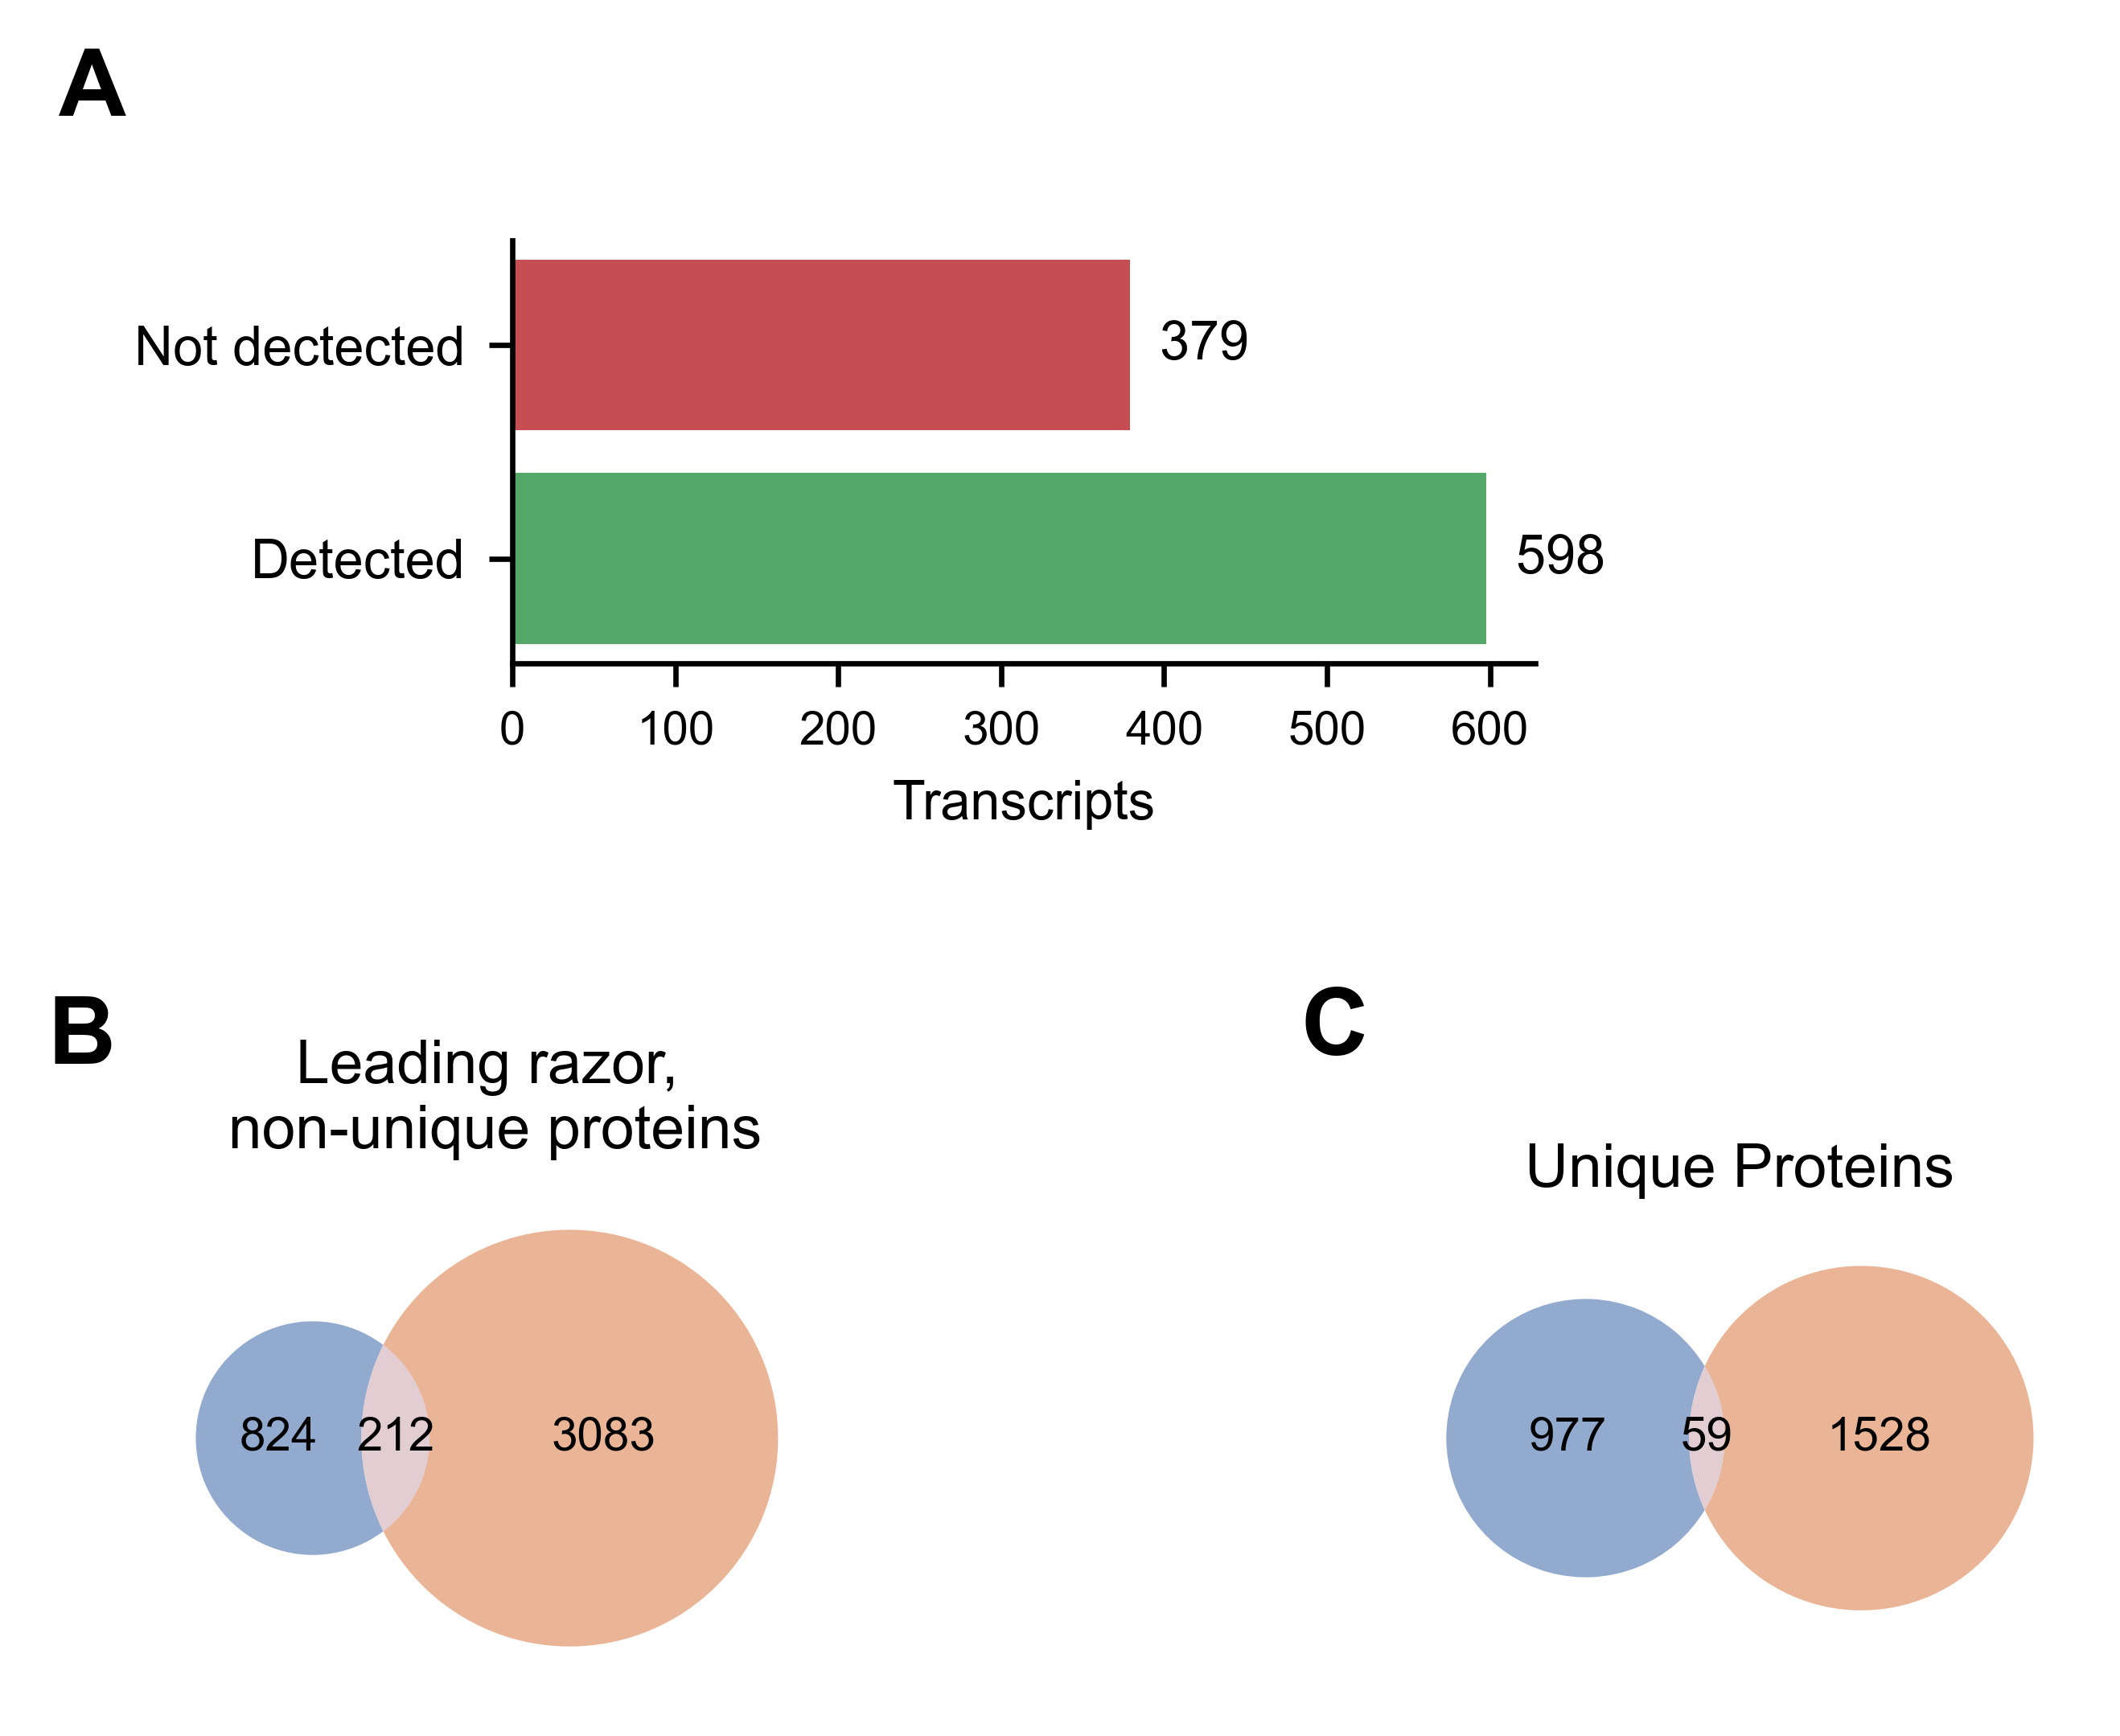

PFAM-missed transcripts (expand-all variant universe): 977
Detected under variant: 598
Not detected under variant: 379


In [6]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

strict_title = panel_data.panel_titles[0]  # edit to override Panel A title
relaxed_title = panel_data.panel_titles[1]  # edit to override Panel B title
strict_labels = ("PFAM (A ∪ B)", "Mass spec (unique)")
relaxed_labels = ("PFAM (A ∪ B)", panel_data.relaxed_label)

venn_title_fontsize = getattr(PANEL_STYLE, 'venn_title_fontsize', None)
venn_label_fontsizes = getattr(PANEL_STYLE, 'venn_set_label_fontsizes', None)
if venn_label_fontsizes and not any(size is not None for size in venn_label_fontsizes):
    venn_label_fontsizes = None

panelC_title = f"Detection among PFAM-missed ({panel_data.panelC_variant_label})"
panelC_detected_label = "Detected at all"
panelC_not_detected_label = "Not detected"
panelC_xlabel = "PFAM (A ∪ B) transcripts missed in Panel A (count)"
panelC_title_fontsize = 8
panelC_axis_fontsize = 8
panelC_hide_box = True  # set False to keep the full bounding box

print('[SupFig3] Building revised gridspec panel with PFAM vs mass-spec overlaps...')

plt.rcParams['font.family'] = 'sans-serif'
preferred_fonts = ['Arial', 'DejaVu Sans', 'Liberation Sans']
existing_fonts = plt.rcParams.get('font.sans-serif', [])
plt.rcParams['font.sans-serif'] = preferred_fonts + [f for f in existing_fonts if f not in preferred_fonts]
plt.rcParams['font.size'] = 7
plt.rcParams['axes.titlesize'] = 7
plt.rcParams['axes.labelsize'] = 7
plt.rcParams['legend.fontsize'] = 7
plt.rcParams.update({
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
})

fig = plt.figure(figsize=(8, 11), dpi=600)
gs = gridspec.GridSpec(
    15,
    17,
    height_ratios=[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    hspace=1.0,
    wspace=0.4,
    figure=fig,
)

ax_strict = fig.add_subplot(gs[3:6, 7:11])
s3.plot_two_set_venn(
    panel_data.union_size,
    panel_data.strict_size,
    panel_data.strict_overlap,
    labels=None,
    title="Unique Proteins",
    title_fontsize=venn_title_fontsize,
    set_label_fontsizes=venn_label_fontsizes,
    ax=ax_strict,
    set_colors=PANEL_STYLE.venn_colors,
    alpha=PANEL_STYLE.venn_alpha,
)

ax_relaxed = fig.add_subplot(gs[3:6, 0:4])
s3.plot_two_set_venn(
    panel_data.union_size,
    panel_data.relaxed_size,
    panel_data.relaxed_overlap,
    labels=None,
    title="Leading razor,\n non-unique proteins",
    title_fontsize=venn_title_fontsize,
    set_label_fontsizes=venn_label_fontsizes,
    ax=ax_relaxed,
    set_colors=PANEL_STYLE.venn_colors,
    alpha=PANEL_STYLE.venn_alpha,
)

ax_missed = fig.add_subplot(gs[0:2, 2:8])
panelC_detected = panel_data.panelC_detected_count
panelC_not = panel_data.panelC_not_detected_count
bars = [panelC_detected, panelC_not]
bar_labels = ["Detected", "Not dectected"]
ax_missed.barh([0, 1], bars, color=PANEL_STYLE.panel_c_colors)
ax_missed.set_yticks([0, 1])
ax_missed.set_yticklabels(bar_labels, fontsize=panelC_axis_fontsize)
ax_missed.set_xlabel("Transcripts", fontsize=panelC_axis_fontsize)
#ax_missed.set_title(panelC_title, fontsize=panelC_title_fontsize)
ax_missed.tick_params(axis='y', labelsize=panelC_axis_fontsize)
for idx, val in enumerate(bars):
    ax_missed.text(val, idx, f'  {val}', va='center', ha='left', fontsize=panelC_axis_fontsize)

if panelC_hide_box:
    for spine_name in ('top', 'right'):
        spine = ax_missed.spines.get(spine_name)
        if spine is not None:
            spine.set_visible(False)
    for spine_name in ('bottom', 'left'):
        spine = ax_missed.spines.get(spine_name)
        if spine is not None:
            spine.set_visible(True)

def place_panel_label(fig, axis, label, x_pad=-0.01, y_pad=0.02):
    bbox = axis.get_position()
    fig.text(
        bbox.x0 + x_pad,
        bbox.y1 + y_pad,
        label,
        fontsize=14,
        fontweight='bold',
        ha='right',
        va='bottom',
    )

place_panel_label(fig, ax_strict, 'C',y_pad=0.029)
place_panel_label(fig, ax_relaxed, 'B')
place_panel_label(fig, ax_missed, 'A',x_pad=-0.1)

fig.tight_layout()
MANUAL_GRID_PNG = FIGURE_DIR / f'Sup_Figure_3_gridspec_{panel_data.relaxed_suffix}_notebook.png'
fig.savefig(MANUAL_GRID_PNG, dpi=600)
plt.show()
plt.close(fig)

print(f"PFAM-missed transcripts (expand-all variant universe): {len(panel_data.missed_after_strict):,}")
print(f"Detected under variant: {panelC_detected:,}")
print(f"Not detected under variant: {panelC_not:,}")




In [3]:
panel_paths = s3.generate_sup_fig3_panels(
    panel_data=panel_data,
    out_dir=FIGURE_DIR,
    panel_style=PANEL_STYLE,
    figure_data_dir=FIGURE_DATA_DIR,
)
print('Panel files written:')
pprint(panel_paths)


Panel files written:
{'composed_png': '/mnt/data1/Ovary_repro_aging/flair/for_pub/Sup_Figure_3/figure_files/supp_fig3_outputs/supp_fig3_panels_relaxed_leading2peps_gridspec.png',
 'panelA_pdf': '/mnt/data1/Ovary_repro_aging/flair/for_pub/Sup_Figure_3/figure_files/supp_fig3_outputs/supp_fig3_panelA_strict.pdf',
 'panelA_png': '/mnt/data1/Ovary_repro_aging/flair/for_pub/Sup_Figure_3/figure_files/supp_fig3_outputs/supp_fig3_panelA_strict.png',
 'panelA_svg': '/mnt/data1/Ovary_repro_aging/flair/for_pub/Sup_Figure_3/figure_files/supp_fig3_outputs/supp_fig3_panelA_strict.svg',
 'panelB_pdf': '/mnt/data1/Ovary_repro_aging/flair/for_pub/Sup_Figure_3/figure_files/supp_fig3_outputs/supp_fig3_panelB_relaxed_leading2peps.pdf',
 'panelB_png': '/mnt/data1/Ovary_repro_aging/flair/for_pub/Sup_Figure_3/figure_files/supp_fig3_outputs/supp_fig3_panelB_relaxed_leading2peps.png',
 'panelB_svg': '/mnt/data1/Ovary_repro_aging/flair/for_pub/Sup_Figure_3/figure_files/supp_fig3_outputs/supp_fig3_panelB_relaxed_

/mnt/data1/Ovary_repro_aging/flair/for_pub/Sup_Figure_3/Sup_Figure_3_module.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


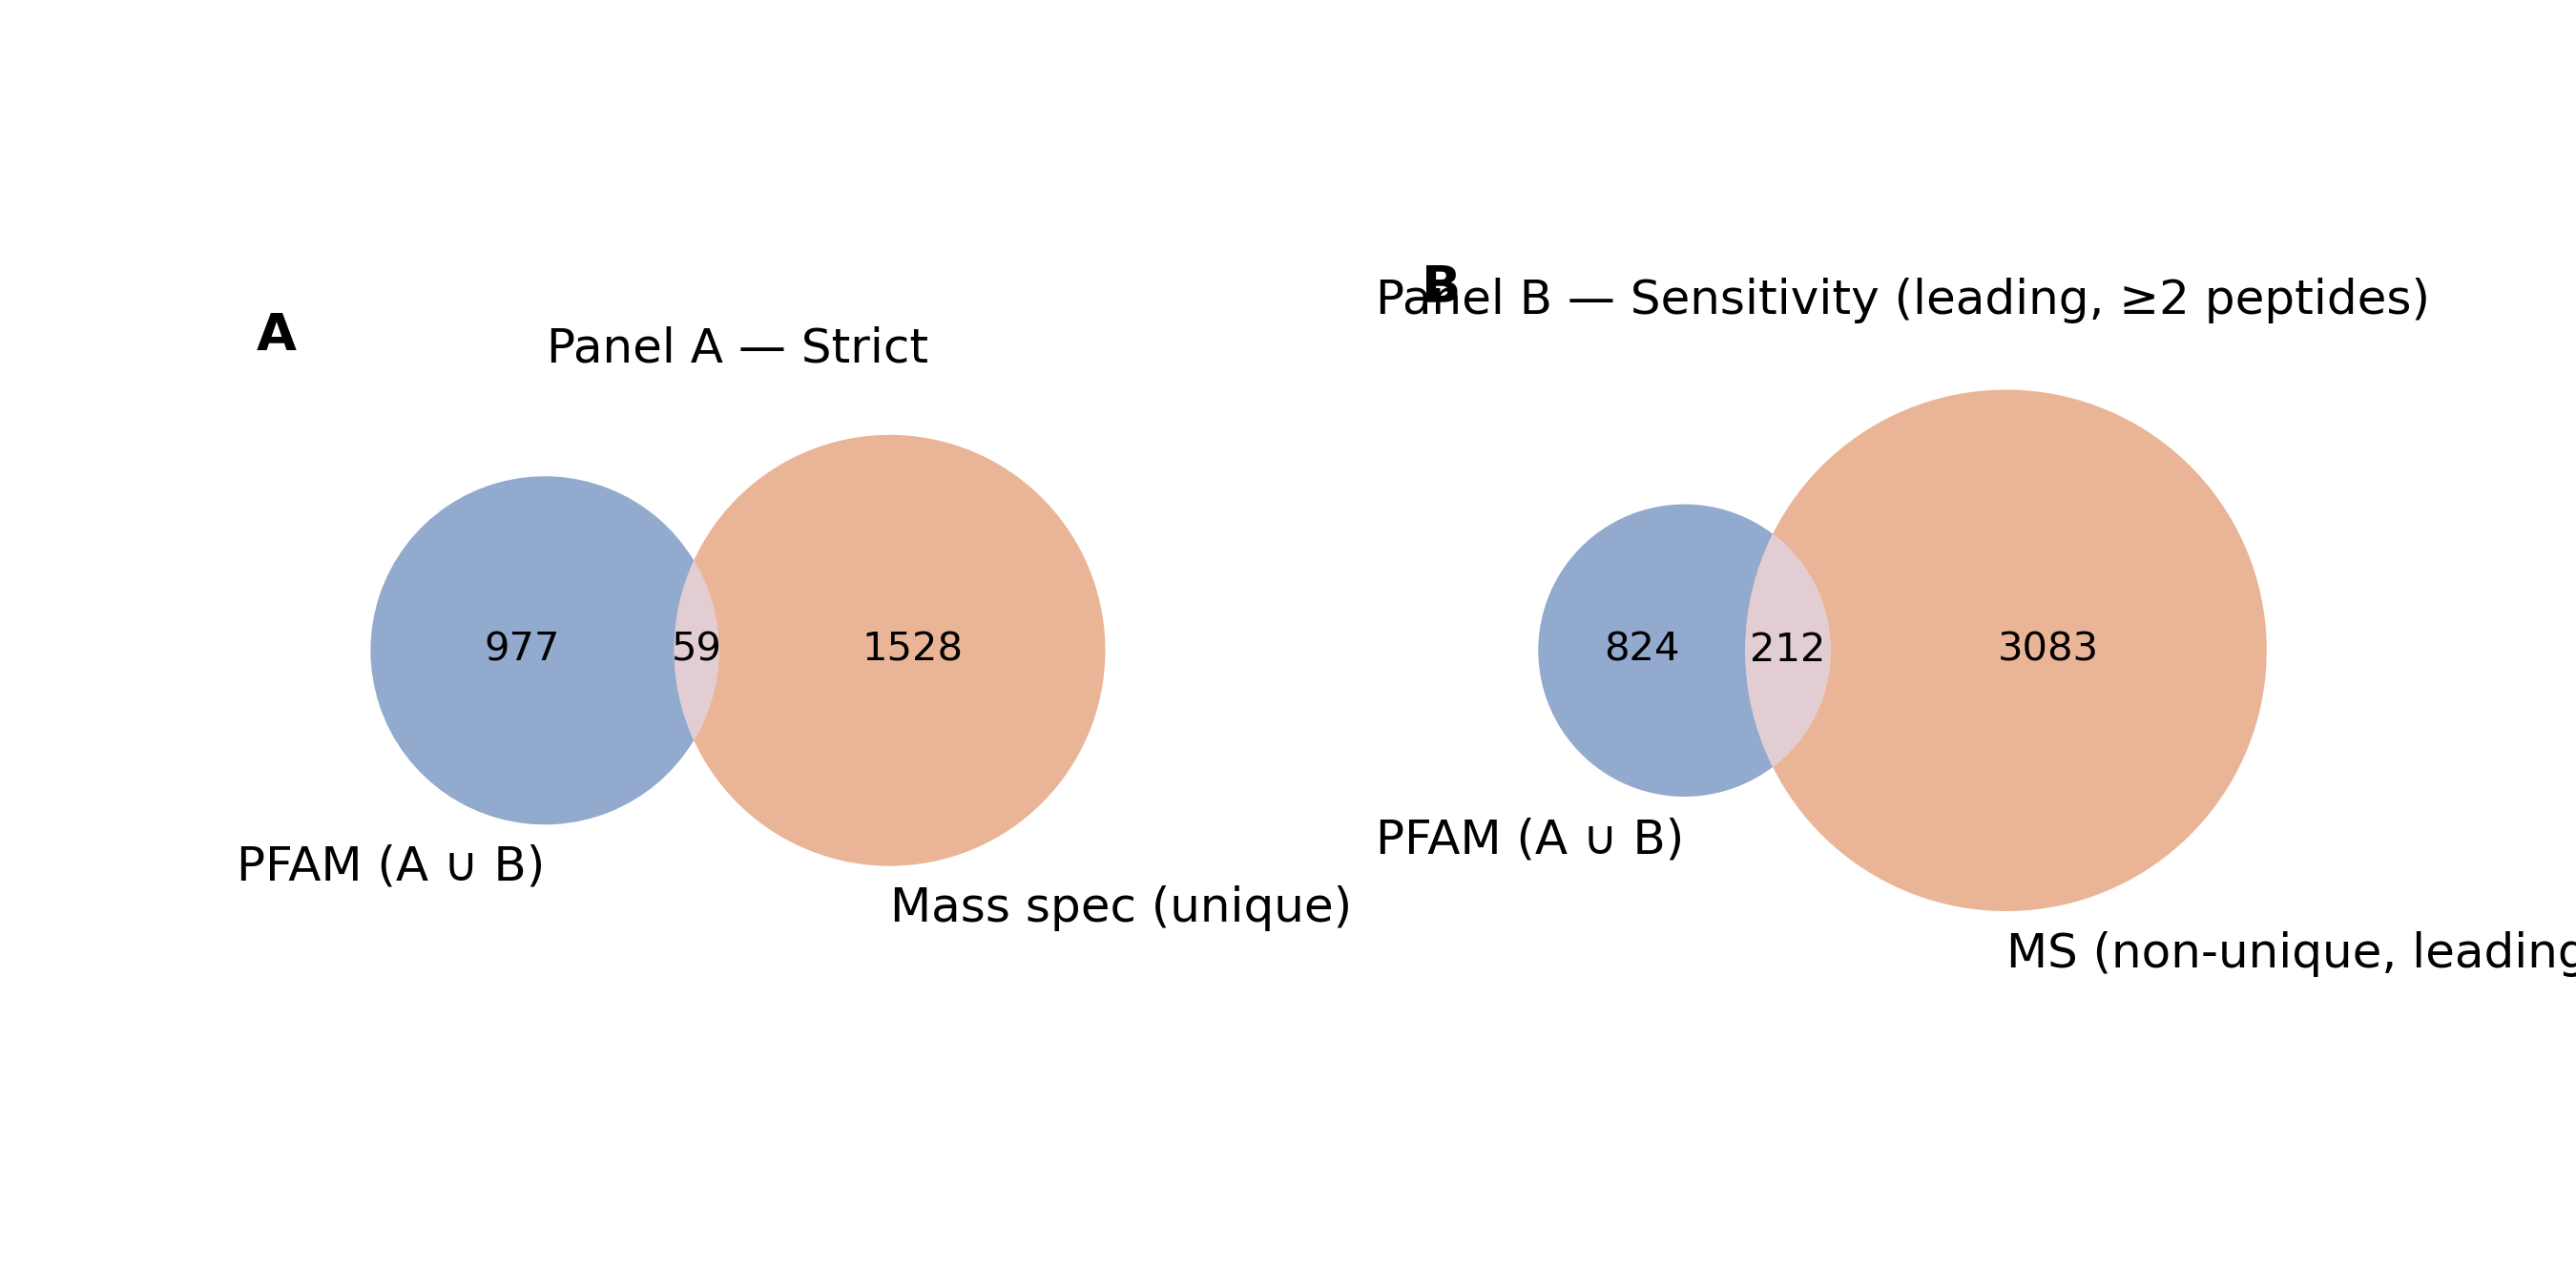

In [4]:
from pathlib import Path
from IPython.display import Image, display

grid_preview = MANUAL_GRID_PNG if 'MANUAL_GRID_PNG' in globals() and Path(MANUAL_GRID_PNG).exists() else panel_paths.get('panels_gridspec_png')
panelC_preview = panel_paths.get('panelC_png')
if grid_preview and Path(grid_preview).exists():
    display(Image(filename=grid_preview))
else:
    print('Combined gridspec figure not found:', grid_preview)

if panelC_preview and Path(panelC_preview).exists():
    display(Image(filename=panelC_preview))
else:
    print('Panel C figure not found:', panelC_preview)



In [5]:
panelA_counts = json.loads((OUT / 'panelA_counts.json').read_text())
panelB_counts = json.loads((OUT / 'panelB_counts.json').read_text())
panelC_counts = json.loads((OUT / 'panelC_expandAll_any_counts.json').read_text())
pd.DataFrame(
    [panelA_counts, panelB_counts, panelC_counts],
    index=['Panel A — strict', f"Panel B — {SENSITIVITY_PRESET}", 'Panel C — expand-all (≥1 peptide)'],
)



,pfam_union_size,ms_size,overlap,preset
Panel A — strict,1036,1587,59,NaN
Panel B — leading_2peps,1036,3295,212,leading_2peps


In [ ]:
strict_df = pd.read_csv(OUT / 'pfam_union_with_ms_STRICT.csv')
relaxed_csv = OUT / f"pfam_union_with_ms_{panel_data.relaxed_suffix.upper()}.csv"
relaxed_df = pd.read_csv(relaxed_csv) if relaxed_csv.exists() else None
panelC_detected_df = pd.read_csv(OUT / 'missed_detected_panelC_expandAll_any.csv')
panelC_not_df = pd.read_csv(OUT / 'missed_NOT_detected_panelC_expandAll_any.csv')

print(f"Strict overlap rows: {len(strict_df):,}")
strict_df.head()

if relaxed_df is not None:
    print(f"Relaxed overlap rows: {len(relaxed_df):,}")
    relaxed_df.head()

print(f"Panel C detected rows: {len(panelC_detected_df):,}")
panelC_detected_df.head()
print(f"Panel C NOT detected rows: {len(panelC_not_df):,}")
panelC_not_df.head()



### Notes
- Switch `SENSITIVITY_PRESET` between `leading_2peps` and `expandAll_2peps` before re-running the generation cell to compare strict vs upper-bound sensitivity.
- `SupFigure3PanelStyle` mirrors the Sup Fig 4 workflow — tweak its parameters (fonts, gridspec span, panel labels, Panel C colors) and re-run to restyle the figure trio.
- Outputs are idempotent — re-running cells refreshes the panels, JSON summaries (including Panel C), and overlap tables in-place.
- Install `matplotlib-venn` in the active environment before running the Venn cells.
